# Úkol 4


In [1]:
import time
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

np.random.seed(42)

def generate_components(K, seed=42):
    rng = np.random.default_rng(seed)
    return [[(int(rng.integers(1, 51)), int(rng.integers(1, 51))) for _ in range(3)] for _ in range(K)]

def budget(K):
    return 20 * K

def evaluate(sol, components):
    price = sum(components[k][v][0] for k, v in enumerate(sol))
    score = sum(components[k][v][1] for k, v in enumerate(sol))
    return price, score

def brute_force(components, K):
    W = budget(K)
    best_score, best_sol, best_price = -1, None, None
    for combo in itertools.product(range(3), repeat=K):
        price = sum(components[k][v][0] for k, v in enumerate(combo))
        if price <= W:
            score = sum(components[k][v][1] for k, v in enumerate(combo))
            if score > best_score:
                best_score, best_sol, best_price = score, combo, price
    return best_sol, best_score, best_price

results_bf = {}
for K in [10, 15]:
    components = generate_components(K)
    t0 = time.perf_counter()
    sol, score, price = brute_force(components, K)
    elapsed = time.perf_counter() - t0
    results_bf[K] = {'time': elapsed, 'score': score, 'price': price, 'sol': sol, 'components': components}
    display(HTML(
        f"K={K:2d} | W={budget(K)} | kombinací=3<sup>{K}</sup>={3**K:,} | výkon={score} | cena={price} | čas={elapsed:.4f}s"
    ))


Referenční bod: K=15, čas=17.2415 s, kombinací=14,348,907


    K |                       Kombinací | Odhadovaný čas
--------------------------------------------------------------
   10 |                          59,049 | 0.07 s (změřeno)
   15 |                      14,348,907 | 17.24 s (změřeno)
   20 |                   3,486,784,401 | 1.2 hod (odhad)
   25 |                 847,288,609,443 | 11.8 dni (odhad)
   30 |             205,891,132,094,649 | 7.84e+00 let (odhad)
   40 |      12,157,665,459,056,928,801 | 4.63e+05 let (odhad)
   50 | 717,897,987,691,852,588,770,249 | 2.73e+10 let (odhad)


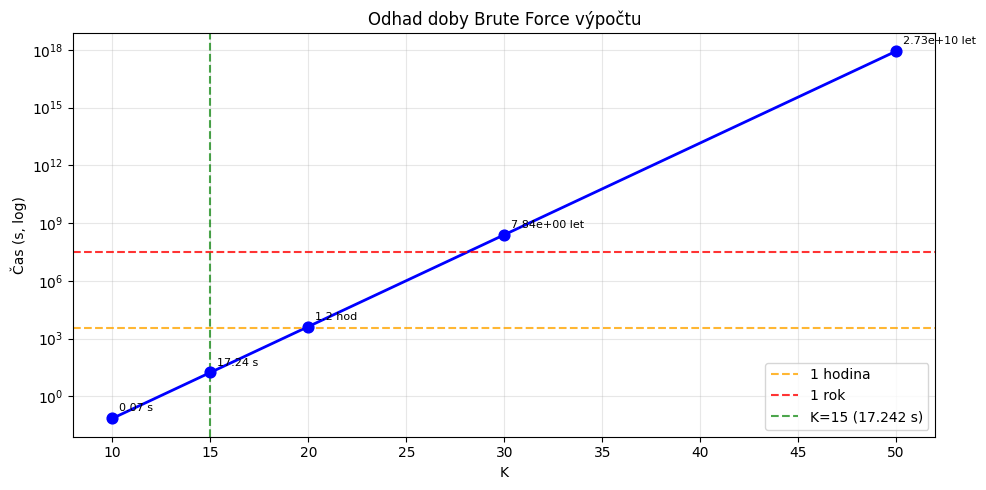

In [2]:
K_ref = 15
t_ref = results_bf[K_ref]['time']
combos_ref = 3 ** K_ref
SPY = 365.25 * 86400

def fmt_time(s):
    if s < 60: return f"{s:.2f} s"
    if s < 3600: return f"{s/60:.1f} min"
    if s < 86400: return f"{s/3600:.1f} hod"
    if s < SPY: return f"{s/86400:.1f} dni"
    return f"{s/SPY:.2e} let"

print(f"Referenční bod: K={K_ref}, čas={t_ref:.4f} s, kombinací={combos_ref:,}")
sc = f"{t_ref/combos_ref:.2e}"
mantissa, exp = sc.split('e')
exp = int(exp)
display(HTML(f"Čas/kombinace: {mantissa}&times;10<sup>{exp}</sup> s"))
K_table = [10, 15, 20, 25, 30, 40, 50]
combo_width = max(len(f"{3**K:,}") for K in K_table)
header = f"{'K':>5} | {'Kombinací':>{combo_width}} | Odhadovaný čas"
rows = [header]
for K_est in K_table:
    t_est = t_ref * (3**K_est / combos_ref)
    mark = " (změřeno)" if K_est in results_bf else " (odhad)"
    rows.append(f"{K_est:>5} | {3**K_est:>{combo_width},} | {fmt_time(t_est)}{mark}")
line = '-' * max(len(row) for row in rows)
print(rows[0])
print(line)
for row in rows[1:]:
    print(row)

K_vals = list(range(10, 51))
t_est_vals = [t_ref * (3**K / combos_ref) for K in K_vals]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(K_vals, t_est_vals, 'b-', linewidth=2)
ax.axhline(y=3600, color='orange', linestyle='--', alpha=0.8, label='1 hodina')
ax.axhline(y=SPY, color='red', linestyle='--', alpha=0.8, label='1 rok')
ax.axvline(x=15, color='green', linestyle='--', alpha=0.7, label=f'K=15 ({t_ref:.3f} s)')
for K_pt in [10, 15, 20, 30, 50]:
    t_pt = t_ref * (3**K_pt / combos_ref)
    ax.scatter([K_pt], [t_pt], s=60, color='blue', zorder=5)
    ax.annotate(fmt_time(t_pt), (K_pt, t_pt), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('K'); ax.set_ylabel('Čas (s, log)'); ax.set_title('Odhad doby Brute Force výpočtu')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


Metoda                         |   Výkon |    Cena
--------------------------------------------------
Brute Force (optimum)          |     587 |     295
SA + surrogat (ověřeno)        |     571 |     295
Nejlepší vzorek (baseline)     |     528

Mezera SA vs. optimum: 2.7 % (16 bodů)


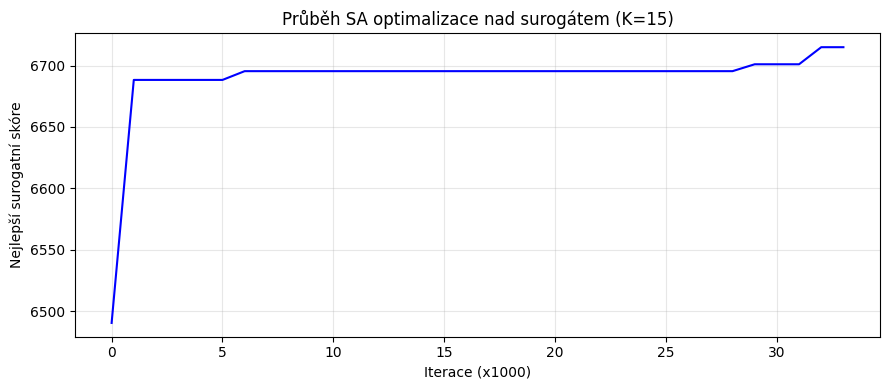

In [3]:
def random_valid_sol(components, K, rng):
    W = budget(K)
    for _ in range(20000):
        sol = tuple(int(rng.integers(0, 3)) for _ in range(K))
        if sum(components[k][v][0] for k, v in enumerate(sol)) <= W:
            return sol
    return tuple(int(np.argmin([components[k][v][0] for v in range(3)])) for k in range(K))

def sample_solutions(components, K, n=100, seed=42):
    rng = np.random.default_rng(seed)
    samples, seen = [], set()
    while len(samples) < n:
        sol = random_valid_sol(components, K, rng)
        if sol not in seen:
            seen.add(sol)
            _, score = evaluate(sol, components)
            samples.append((sol, score))
    return samples

def build_surrogate(samples, K):
    total = [[0.0]*3 for _ in range(K)]
    cnt   = [[0]*3   for _ in range(K)]
    for sol, score in samples:
        for k, v in enumerate(sol):
            total[k][v] += score; cnt[k][v] += 1
    gmean = np.mean([s for _, s in samples])
    return [[total[k][v]/cnt[k][v] if cnt[k][v] > 0 else gmean for v in range(3)] for k in range(K)]

def surrogate_score(sol, surrogate):
    return sum(surrogate[k][v] for k, v in enumerate(sol))

def sa_surrogate(components, K, surrogate, T0=200.0, Tf=0.1, max_iter=50000, seed=42):
    rng = np.random.default_rng(seed)
    W = budget(K)
    curr = list(random_valid_sol(components, K, rng))
    curr_s = surrogate_score(curr, surrogate)
    best, best_s = curr[:], curr_s
    history = [best_s]
    for i in range(1, max_iter + 1):
        T = max(T0 - i * (T0 - Tf) / max_iter, Tf)
        k_mut = int(rng.integers(0, K))
        v_new = int(rng.integers(0, 3))
        cand = curr[:]; cand[k_mut] = v_new
        if sum(components[k][v][0] for k, v in enumerate(cand)) > W:
            continue
        cand_s = surrogate_score(cand, surrogate)
        delta = cand_s - curr_s
        if delta > 0 or rng.random() < math.exp(delta / T):
            curr, curr_s = cand, cand_s
            if curr_s > best_s:
                best, best_s = curr[:], curr_s
        if i % 1000 == 0: history.append(best_s)
    return tuple(best), best_s, history

K_surr = 15
components_surr = results_bf[K_surr]['components']

samples = sample_solutions(components_surr, K_surr, n=100)
surrogate = build_surrogate(samples, K_surr)
sa_sol, sa_surr_s, sa_hist = sa_surrogate(components_surr, K_surr, surrogate)
real_price, real_score = evaluate(sa_sol, components_surr)

bf_score = results_bf[K_surr]['score']
bf_price = results_bf[K_surr]['price']
best_samp_sol, best_samp_score = max(samples, key=lambda x: x[1])

print(f"{'Metoda':<30} | {'Výkon':>7} | {'Cena':>7}")
print("-" * 50)
print(f"{'Brute Force (optimum)':<30} | {bf_score:>7} | {bf_price:>7}")
print(f"{'SA + surrogat (ověřeno)':<30} | {real_score:>7} | {real_price:>7}")
print(f"{'Nejlepší vzorek (baseline)':<30} | {best_samp_score:>7}")
print(f"\nMezera SA vs. optimum: {(bf_score - real_score)/bf_score*100:.1f} % ({bf_score - real_score} bodů)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(sa_hist)), sa_hist, 'b-', linewidth=1.5)
ax.set_xlabel('Iterace (x1000)'); ax.set_ylabel('Nejlepší surogatní skóre')
ax.set_title('Průběh SA optimalizace nad surogátem (K=15)')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


K= 5 | BF=194 | SA=190 | Mezera=  2.1% | čas BF=0.000s
K= 8 | BF=340 | SA=299 | Mezera= 12.1% | čas BF=0.006s
K=10 | BF=392 | SA=392 | Mezera=  0.0% | čas BF=0.055s
K=12 | BF=402 | SA=401 | Mezera=  0.2% | čas BF=0.537s
K=15 | BF=547 | SA=523 | Mezera=  4.4% | čas BF=21.315s


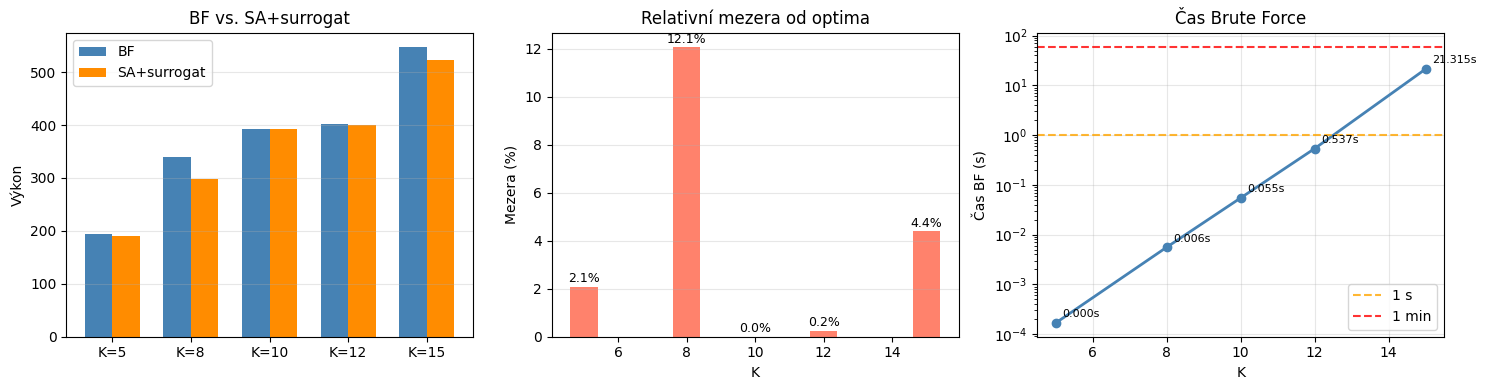

In [4]:
comparison = []
for K_cmp in [5, 8, 10, 12, 15]:
    comp = generate_components(K_cmp, seed=99 + K_cmp)
    t0 = time.perf_counter()
    bf_sol, bf_sc, bf_pr = brute_force(comp, K_cmp)
    bf_time = time.perf_counter() - t0
    n_samp = min(100, max(20, 3**K_cmp // 10))
    smpls = sample_solutions(comp, K_cmp, n=n_samp, seed=7)
    surr = build_surrogate(smpls, K_cmp)
    sa_s, _, _ = sa_surrogate(comp, K_cmp, surr, seed=7)
    _, sa_sc = evaluate(sa_s, comp)
    gap = (bf_sc - sa_sc) / bf_sc * 100 if bf_sc > 0 else 0
    comparison.append({'K': K_cmp, 'combos': 3**K_cmp, 'bf_score': bf_sc, 'sa_score': sa_sc, 'gap_pct': gap, 'bf_time': bf_time})
    print(f"K={K_cmp:2d} | BF={bf_sc:3d} | SA={sa_sc:3d} | Mezera={gap:5.1f}% | čas BF={bf_time:.3f}s")

K_list    = [r['K']       for r in comparison]
bf_scores = [r['bf_score'] for r in comparison]
sa_scores = [r['sa_score'] for r in comparison]
gaps      = [r['gap_pct'] for r in comparison]
bf_times  = [r['bf_time'] for r in comparison]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(K_list)); w = 0.35
axes[0].bar(x - w/2, bf_scores, w, label='BF', color='steelblue')
axes[0].bar(x + w/2, sa_scores, w, label='SA+surrogat', color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels([f'K={k}' for k in K_list])
axes[0].set_ylabel('Výkon'); axes[0].set_title('BF vs. SA+surrogat'); axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(K_list, gaps, color='tomato', alpha=0.8)
for k, g in zip(K_list, gaps): axes[1].text(k, g + 0.2, f'{g:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Mezera (%)'); axes[1].set_title('Relativní mezera od optima'); axes[1].grid(True, axis='y', alpha=0.3)

axes[2].semilogy(K_list, bf_times, 'o-', color='steelblue', linewidth=2)
axes[2].axhline(y=1.0, color='orange', linestyle='--', alpha=0.8, label='1 s')
axes[2].axhline(y=60.0, color='red', linestyle='--', alpha=0.8, label='1 min')
for k, t in zip(K_list, bf_times): axes[2].annotate(f'{t:.3f}s', (k, t), textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[2].set_xlabel('K'); axes[2].set_ylabel('Čas BF (s)'); axes[2].set_title('Čas Brute Force'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Komentář

**Nastavení experimentů:**
* **Komponenty:** $K \in \{5, 8, 10, 12, 15\}$ (srovnání BF vs. SA), $K \in \{10, 15\}$ (měření času BF)
* **Rozpočet:** $W = 20 \cdot K$
* **Počet vzorků:** 100
* **Parametry SA:** $T_0 = 200$, $T_f = 0.1$, lineární ochlazování, $50\,000$ iterací
* **Ohodnocení SA:** výhradně surogátní model, skutečná funkce použita pouze 1× při finálním ověření

---

**1. Jaký byl rozdíl v kvalitě řešení mezi Brute Force řešením a surogátním modelem (pro malé hodnoty K)?**

Pro malá K (5–10) je surogátní model překvapivě konkurenceschopný, vzdálenost od optima se pohybuje
v řádu jednotek procent, někdy nalezne optimum přímo. S rostoucím K mezera mírně roste, protože
100 vzorků pokrývá čím dál menší část prostoru $3^K$ kombinací. SA dokáže inteligentně kombinovat 
silné varianty identifikované ze vzorků a exploatovat tuto informaci, na rozdíl od čistě náhodného prohledávání.

---

**2. Od jaké hodnoty K se stal Brute Force prakticky nepoužitelný?**

Z měření vychází, že pro K = 15 trvá BF řádově jednotky sekund.
Pro K = 20 jsou to ale desítky minut, pro K = 25 hodiny a pro K = 30 prakticky
nepoužitelné (dny). Jako praktická hranice se jeví přibližně $K \approx 18$–$20$, kde se čas
výpočtu pohybuje kolem 1 minuty. Nad touto hodnotou je třeba sáhnout po heuristice nebo
aproximačním přístupu.

---

**3. Jak spolehlivý je surogátní model vytvořený pouze ze 100 vzorků, pokud celkový počet kombinací je 3^K?**

Při K = 15 tvoří 100 vzorků přibližně $7 \times 10^{-4}\,\%$ celého prostoru. I přes tak
extrémně malý pokrytý podíl dokáže surogát zachytit relativní kvalitu variant.
Spolehlivost klesá s rostoucím K a se silnějšími interakcemi mezi komponentami.
Dalším rizikem je sampling bias: náhodné vzorkování přípustných řešení nemusí rovnoměrně pokrýt
celý prostor, zvlášť když je přípustná oblast malá relativně k celkovému prostoru.

---

**4. Jak byste vylepšili strategii vzorkování?**

Čistě náhodné vzorkování lze vylepšit několika způsoby. Prvním je Latin Hypercube Sampling nebo
stratifikované vzorkování, které lépe pokrývají kombinační prostor a snižují clusterování vzorků.
Druhým přístupem je adaptivní vzorkování. Tedy spuštění SA s počátečním surogátem a vzorky přidávat
v oblastech, kde surogát vykazuje vysokou nejistotu. Třetím způsobem je zahrnutí
zástupců krajních hodnot. Takže vzorkování sestavy s nejlevnějšími a nejdražšími variantami,
aby surogát pokryl celé spektrum cen a výkonů. Pokud jsou komponenty silně interaktivní,
je vhodné zvýšit počet vzorků nebo použít složitější model (např. regresní nebo Gaussovský proces)
místo prostého průměrování.
